# Import

In [7]:
from pathlib import Path
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import json
import re


# from logparser import Spell, Drain
import argparse
from tqdm import tqdm

In [8]:
%load_ext autoreload
%autoreload 2
import for_embed
from process_grouper import group_events_by_process, print_summary

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
PROCESSED_DIR = Path("../data/processed")
INTERIM_DIR = Path("../data/interim")
RAW_DIR = Path("../data/raw")
TMP_DIR = Path("../tmp")

# 関数定義

In [10]:
def plot_sequence_length_distribution(
    file_path: Path
):
    """
    全行のシーケンス長を計算し、
    各長さに対するサンプル数を集計して
    シーケンス長の昇順でプロットする

    Parameters
    ----------
    file_path : Path
        入力データファイル
    """
    sequence_lengths = []

    # 各行のシーケンス長を計算
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            tokens = line.split()
            sequence_lengths.append(len(tokens))

    # 長さごとのサンプル数を集計
    length_counter = Counter(sequence_lengths)

    # 昇順ソート
    lengths = sorted(length_counter.keys())
    counts = [length_counter[l] for l in lengths]

    # プロット
    plt.figure()
    plt.plot(lengths, counts, marker="o")
    plt.xlabel("Sequence Length")
    plt.ylabel("Number of Samples")
    plt.title("Sequence Length Distribution (Sorted by Length)")
    plt.grid(True)
    plt.show()

In [11]:
def plot_element_frequency(
    file_path: Path,
    min_frequency: int = 0, 
):
    """
    ファイル中の要素（ID）をカウントし，
    出現頻度が min_frequency 以上のもののみをプロットする

    Parameters
    ----------
    file_path : Path
        入力データファイル
    min_frequency : int
        プロット対象とする最小出現回数（閾値）
    """
    elements = []

    # ファイル読み込み
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            tokens = line.split()
            for token in tokens:
                element = token.split(",")[0]
                elements.append(element)

    # 出現頻度を集計
    counter = Counter(elements)

    # 閾値以上の要素のみ抽出
    filtered_items = [
        (elem, cnt)
        for elem, cnt in counter.items()
        if cnt >= min_frequency
    ]

    # 頻度降順でソート（見やすさ重視）
    filtered_items.sort(key=lambda x: x[1], reverse=True)

    if len(filtered_items) == 0:
        print("閾値を満たす要素がありません。")
        return

    labels = [item[0] for item in filtered_items]
    counts = [item[1] for item in filtered_items]

    # プロット
    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts)
    plt.xlabel("Element (ID)")
    plt.ylabel("Frequency")
    plt.title(f"Element Frequency (>= {min_frequency})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [12]:
def plot_second_value_frequency(
    file_path: Path,
    min_frequency: int = 0,
):
    """
    スペース区切りのベクトル
    (例: '5158,0,0.61 5156,1,2.60 ...')
    における「2番目の値（index=1）」の出現頻度を集計・プロットする。

    Parameters
    ----------
    file_path : Path
        入力データファイル
    min_frequency : int
        プロット対象とする最小出現回数
    """

    second_values = []

    # ファイル読み込み
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            tokens = line.split()

            for token in tokens:
                parts = token.split(",")

                # 少なくとも2番目の要素があるか確認
                if len(parts) >= 2:
                    second_values.append(parts[1])

    # 出現頻度を集計
    counter = Counter(second_values)

    # 閾値以上のみ抽出
    filtered_items = [
        (value, cnt)
        for value, cnt in counter.items()
        if cnt >= min_frequency
    ]

    # 頻度降順でソート
    filtered_items.sort(key=lambda x: x[1], reverse=True)

    if not filtered_items:
        print("閾値を満たす値がありません。")
        return

    labels = [item[0] for item in filtered_items]
    counts = [item[1] for item in filtered_items]

    # プロット
    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts)
    plt.xlabel("Second Value (index=1)")
    plt.ylabel("Frequency")
    plt.title(f"Second Value Frequency (>= {min_frequency})")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_second_value_ratio(
    file_path: Path,
    min_ratio: float = 0.0,
):
    """
    スペース区切りのベクトル
    (例: '5158,0,0.61 5156,1,2.60 ...')
    における「2番目の値（index=1）」の割合（%）を算出・プロットする。

    Parameters
    ----------
    file_path : Path
        入力データファイル
    min_ratio : float
        プロット対象とする最小割合（%）
    """

    second_values = []

    # ファイル読み込み
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            tokens = line.split()
            for token in tokens:
                parts = token.split(",")
                if len(parts) >= 2:
                    second_values.append(parts[1])

    if not second_values:
        print("有効なデータがありません。")
        return

    # 出現頻度を集計
    counter = Counter(second_values)
    total = sum(counter.values())

    # 割合（%）を計算
    ratio_items = [
        (value, cnt / total * 100.0)
        for value, cnt in counter.items()
        if (cnt / total * 100.0) >= min_ratio
    ]

    # 割合の降順でソート
    ratio_items.sort(key=lambda x: x[1], reverse=True)

    if not ratio_items:
        print("閾値を満たす値がありません。")
        return

    labels = [item[0] for item in ratio_items]
    ratios = [item[1] for item in ratio_items]

    # プロット
    plt.figure(figsize=(8, 5))
    plt.bar(labels, ratios)
    plt.xlabel("Second Value (index=1)")
    plt.ylabel("Ratio (%)")
    plt.title(f"Second Value Ratio (>= {min_ratio}%)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_windows_event_id_frequency(
    file_path: Path,
    min_frequency: int = 0,
):
    """
    スペース区切りのデータ
    (例: '5158,0,0.61 5156,0,2.60 ...')
    から WindowsイベントID（先頭要素）を抽出し，
    出現頻度を集計・プロットする。

    Parameters
    ----------
    file_path : Path
        入力データファイル
    min_frequency : int
        プロット対象とする最小出現回数
    """

    event_ids = []

    # ファイル読み込み
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # スペース区切りで各要素を取得
            tokens = line.split()

            for token in tokens:
                # "5158,0,0.61" → "5158"
                parts = token.split(",")
                if len(parts) >= 1:
                    event_ids.append(parts[0])

    # 出現頻度を集計
    counter = Counter(event_ids)

    # 閾値以上のみ抽出
    filtered_items = [
        (event_id, cnt)
        for event_id, cnt in counter.items()
        if cnt >= min_frequency
    ]

    # 出現頻度の降順でソート
    filtered_items.sort(key=lambda x: x[1], reverse=True)

    if not filtered_items:
        print("閾値を満たすWindowsイベントIDがありません。")
        return

    labels = [item[0] for item in filtered_items]
    counts = [item[1] for item in filtered_items]

    # プロット
    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts)
    plt.xlabel("Windows Event ID")
    plt.ylabel("Frequency")
    plt.title(f"Windows Event ID Frequency (>= {min_frequency})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_column_value_frequency(
    csv_path: Path,
    column_name: str,
    min_frequency: int = 0,
    label_col: str = "Label",
    compare_labels: bool = False,
    figsize=(14, 6),
):
    """
    CSVの指定したカラムについて、ユニークな値を取得し、
    その頻度をカウントして、出現頻度がmin_frequency以上のもののみをプロットする。
    Label カラムが "-" と "anomaly" の場合で比較できるようにする。
    Parameters
    ----------
    csv_path : Path
        入力CSVファイルパス
    column_name : str
        対象カラム名
    min_frequency : int
        プロット対象とする最小出現回数（閾値）
    label_col : str
        ラベルカラム名（デフォルト: "Label"）
    compare_labels : bool
        Trueの場合、"-" と "anomaly" を比較するプロットを生成
    figsize : tuple
        図のサイズ
    """
    df = pd.read_csv(csv_path)
    
    if compare_labels:
        # Label が "-" のデータ
        df_normal = df[df[label_col] == "-"]
        # Label が "anomaly" のデータ
        df_anomaly = df[df[label_col] == "anomaly"]
        
        # 各カラムの頻度をカウント
        counter_normal = Counter(df_normal[column_name].dropna())
        counter_anomaly = Counter(df_anomaly[column_name].dropna())
        
        # 閾値以上の要素のみ抽出（両方のカウンタから）
        all_keys = set(counter_normal.keys()) | set(counter_anomaly.keys())
        filtered_keys = [
            key for key in all_keys
            if counter_normal.get(key, 0) >= min_frequency 
            or counter_anomaly.get(key, 0) >= min_frequency
        ]
        
        if len(filtered_keys) == 0:
            print("閾値を満たす要素がありません。")
            return
        
        # 頻度降順でソート（合計値ベース）
        filtered_keys.sort(
            key=lambda x: counter_normal.get(x, 0) + counter_anomaly.get(x, 0),
            reverse=True
        )
        
        normal_counts = [counter_normal.get(k, 0) for k in filtered_keys]
        anomaly_counts = [counter_anomaly.get(k, 0) for k in filtered_keys]
        
        # プロット
        x = np.arange(len(filtered_keys))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=figsize)
        bars1 = ax.bar(x - width/2, normal_counts, width, label='Normal (-)', color='steelblue')
        bars2 = ax.bar(x + width/2, anomaly_counts, width, label='Anomaly', color='coral')
        
        ax.set_xlabel(column_name)
        ax.set_ylabel("Frequency")
        ax.set_title(f"{column_name} Frequency Comparison (>= {min_frequency})")
        ax.set_xticks(x)
        ax.set_xticklabels(filtered_keys, rotation=90)
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
    else:
        # 通常の単一カウント
        counter = Counter(df[column_name].dropna())
        
        # 閾値以上の要素のみ抽出
        filtered_items = [
            (elem, cnt)
            for elem, cnt in counter.items()
            if cnt >= min_frequency
        ]
        
        if len(filtered_items) == 0:
            print("閾値を満たす要素がありません。")
            return
        
        # 頻度降順でソート
        filtered_items.sort(key=lambda x: x[1], reverse=True)
        
        labels = [item[0] for item in filtered_items]
        counts = [item[1] for item in filtered_items]
        
        # プロット
        plt.figure(figsize=figsize)
        plt.bar(labels, counts, color='steelblue')
        plt.xlabel(column_name)
        plt.ylabel("Frequency")
        plt.title(f"{column_name} Frequency (>= {min_frequency})")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

In [16]:
def build_drain_eventid_mapping(
    structured_log_path: Path
) -> dict:
    """
    Drain による構造化ログから，
    EventId（Drain）→ EventID（元ログ）
    の対応を復元する

    Parameters
    ----------
    structured_log_path : Path
        Drain 構造化結果（CSV）
        必須カラム: EventId, EventID

    Returns
    -------
    dict
        {Drain_EventId: Original_EventID}
    """
    df = pd.read_csv(structured_log_path)

    # EventId ごとに EventID の最頻値を採用
    mapping_series = (
        df.groupby("EventId")["EventID"]
        .agg(lambda x: x.mode().iloc[0])
    )

    return mapping_series.to_dict()

In [17]:
def plot_eventid_timeline(
    csv_path: Path,
    start: str,
    end: str,
    eventid_col: str = "EventID",
    time_col: str = "TimeCreated_SystemTime",
    kind: str = "scatter",   # "scatter" or "line"
    figsize=(12, 4),
):
    """
    指定区間の EventID 推移をプロットする（横軸: 時刻、縦軸: EventID）

    Parameters
    ----------
    csv_path : Path
        入力CSV
    time_col : str
        タイムスタンプ列名（例: "Timestamp", "datetime" など）
    eventid_col : str
        EventID 列名（デフォルト: "EventID"）
    start, end : str
        抽出する時間範囲（ISO 8601推奨。例: "2023-11-23 16:22:06+00:00"）
    kind : str
        "scatter"（推奨）または "line"
    """
    df = pd.read_csv(csv_path)

    # 例: "2023-11-23 16:22:06.979254+00:00" を正しく解釈（timezone付き）
    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    df[eventid_col] = pd.to_numeric(df[eventid_col], errors="coerce")

    df = df.dropna(subset=[time_col, eventid_col])

    start_ts = pd.to_datetime(start, utc=True)
    end_ts = pd.to_datetime(end, utc=True)

    # 指定区間でフィルタ
    sub = df[(df[time_col] >= start_ts) & (df[time_col] <= end_ts)].copy()
    if sub.empty:
        print("指定した時間区間にデータがありません。")
        return

    # 時刻順に整列
    sub = sub.sort_values(time_col)

    # プロット
    plt.figure(figsize=figsize)
    if kind == "line":
        plt.plot(sub[time_col], sub[eventid_col])
    else:
        # EventID は離散値なので scatter の方が見やすいことが多い
        plt.scatter(sub[time_col], sub[eventid_col], s=8)

    plt.xlabel("Time (UTC)")
    plt.ylabel(eventid_col)
    plt.title(f"{eventid_col} Timeline ({start_ts} to {end_ts})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def export_event_frequency_json(
    df: pd.DataFrame, 
    output_path: Path):
    """
    df: EventID, Content を持つ DataFrame
    output_path: 書き出す JSON ファイルパス
    """

    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    temp = df.copy()

    # "A=B|C=D|..." → ["A=B","C=D"...]
    temp["pairs"] = temp["Content"].str.split("|")
    temp = temp.explode("pairs").dropna()

    # "Key=Value" を分割
    temp[["Attribute", "Value"]] = temp["pairs"].str.split("=", 1, expand=True)

    # 集計: EventID × Attribute × Value
    freq = (
        temp.groupby(["EventID", "Attribute", "Value"])
            .size()
            .reset_index(name="Count")
    )

    # JSON 形式へ整形（階層構造）
    result = {}

    for _, row in freq.iterrows():
        eid = str(row["EventID"])
        attr = row["Attribute"]
        val = row["Value"]
        cnt = int(row["Count"])

        result.setdefault(eid, {})
        result[eid].setdefault(attr, {})
        result[eid][attr][val] = cnt

    # JSON 保存 (UTF-8, インデント付き)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)

    return result

In [19]:
def export_event_unique_count_json(
    df: pd.DataFrame,
    output_path: Path
):
    """
    EventIDごとに、df内での出現数と各属性のユニークな値の数をカウントし、JSONで出力する
    
    Parameters:
    -----------
    df : pd.DataFrame
        EventID, Contentカラムを持つDataFrame
    output_path : Path
        出力先JSONファイルのパス
        
    Returns:
    --------
    dict
        EventID -> {"count": 出現数, "attributes": {属性: ユニーク数}} の辞書
    """
    
    # ディレクトリを確実に作成
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Output directory created: {output_path.parent}")
    
    # データの検証
    print(f"DataFrame shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    if 'EventID' not in df.columns or 'Content' not in df.columns:
        raise ValueError("DataFrame must have 'EventID' and 'Content' columns")
    
    # 欠損値を除外してコピー
    temp = df[['EventID', 'Content']].dropna().copy()
    print(f"Non-null records: {len(temp)}")
    
    if len(temp) == 0:
        print("WARNING: No valid data to process. Creating empty JSON.")
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump({}, f, ensure_ascii=False, indent=2)
        return {}
    
    # Contentを文字列型に変換
    temp['Content'] = temp['Content'].astype(str)
    
    # EventIDごとの出現回数をカウント
    event_counts = temp['EventID'].value_counts().to_dict()
    
    # 結果を格納する辞書（EventID -> Attribute -> Set of unique values）
    unique_values = defaultdict(lambda: defaultdict(set))
    
    # 各レコードを処理
    processed_records = 0
    for _, row in temp.iterrows():
        event_id = str(row['EventID'])
        content = row['Content']
        
        # "Key=Value|Key2=Value2" 形式を分解
        pairs = content.split('|')
        
        for pair in pairs:
            if '=' in pair:
                # "Key=Value" を分割
                parts = pair.split('=', 1)
                if len(parts) == 2:
                    key = parts[0].strip()
                    value = parts[1].strip()
                    
                    # この属性のユニークな値をセットに追加
                    if key and value:  # 空文字列でないことを確認
                        unique_values[event_id][key].add(value)
        
        processed_records += 1
        if processed_records % 10000 == 0:
            print(f"  Processed {processed_records} records...")
    
    print(f"Total processed records: {processed_records}")
    
    # 結果を整形：各EventIDについて出現数と属性のユニーク数を含める
    result_dict = {}
    for event_id in unique_values.keys():
        result_dict[event_id] = {
            "count": int(event_counts.get(int(event_id) if event_id.isdigit() else event_id, 0)),
            "attributes": {
                attribute: len(values)
                for attribute, values in unique_values[event_id].items()
            }
        }
    
    # EventIDを出現数の多い順にソート
    result_dict = dict(sorted(
        result_dict.items(),
        key=lambda x: x[1]["count"],
        reverse=True
    ))
    
    # 統計情報を表示
    print(f"\nProcessing summary:")
    print(f"  Unique EventIDs: {len(result_dict)}")
    if result_dict:
        print(f"\n  Top 3 EventIDs by count:")
        for idx, (event_id, data) in enumerate(list(result_dict.items())[:3], 1):
            print(f"    {idx}. EventID {event_id}: {data['count']} occurrences, {len(data['attributes'])} attributes")
    
    # JSON形式で保存
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(result_dict, f, ensure_ascii=False, indent=2)
    
    print(f"\nJSON file saved: {output_path}")
    print(f"File size: {output_path.stat().st_size} bytes")
    
    return result_dict


In [20]:
def plot_windows_event_id_ratio(
    file_path: Path,
    min_ratio: float = 0.0,
):
    """
    スペース区切りのデータ
    (例: '5158,0,0.61 5156,0,2.60 ...')
    から WindowsイベントID（先頭要素）を抽出し，
    出現割合（%）を集計・プロットする。

    Parameters
    ----------
    file_path : Path
        入力データファイル
    min_ratio : float
        プロット対象とする最小割合（%）
    """

    event_ids = []

    # ファイル読み込み
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            tokens = line.split()
            for token in tokens:
                parts = token.split(",")
                if len(parts) >= 1:
                    event_ids.append(parts[0])

    if not event_ids:
        print("データがありません。")
        return

    # 出現頻度を集計
    counter = Counter(event_ids)
    total_count = sum(counter.values())

    # 割合（%）を計算
    ratio_items = [
        (event_id, cnt / total_count * 100)
        for event_id, cnt in counter.items()
        if (cnt / total_count * 100) >= min_ratio
    ]

    # 割合の降順でソート
    ratio_items.sort(key=lambda x: x[1], reverse=True)

    if not ratio_items:
        print("閾値を満たすWindowsイベントIDがありません。")
        return

    labels = [item[0] for item in ratio_items]
    ratios = [item[1] for item in ratio_items]

    # プロット
    plt.figure(figsize=(10, 5))
    plt.bar(labels, ratios)
    plt.xlabel("Windows Event ID")
    plt.ylabel("Ratio (%)")
    plt.title(f"Windows Event ID Ratio (>= {min_ratio}%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [21]:
def count_processid_frequency(
    df: pd.DataFrame,
    content_col: str = "Content",
) -> pd.DataFrame:
    """
    Content カラムから ProcessID（表記ゆれ含む）を抽出し、
    ProcessID ごとの出現頻度を集計する。

    Parameters
    ----------
    df : pd.DataFrame
        対象データフレーム
    content_col : str
        ProcessID を含む文字列カラム名

    Returns
    -------
    pd.DataFrame
        columns: ["ProcessID", "count"]
        count は ProcessID が出現した行数
    """

    # 正規表現（大文字小文字無視・位置不定）
    pattern = r"(?i)processid=([^|]+)"

    # ProcessID 抽出
    process_ids = df[content_col].str.extract(pattern)[0]

    # 欠損を除外し、頻度集計
    freq_df = (
        process_ids
        .dropna()
        .value_counts()
        .rename("count")
        .reset_index()
        .rename(columns={"index": "ProcessID"})
    )

    return freq_df

In [22]:
def summarize_processid_with_names(
    df: pd.DataFrame,
    content_col: str = "Content",
) -> pd.DataFrame:
    """
    Content カラムから ProcessID を抽出し、
    紐づく NewProcessName / ProcessName / Application を併せて集計する。

    Parameters
    ----------
    df : pd.DataFrame
        対象データフレーム
    content_col : str
        ログ文字列カラム名

    Returns
    -------
    pd.DataFrame
        columns:
        - ProcessID
        - count
        - NewProcessName
        - ProcessName
        - Application
    """

    patterns = {
        "ProcessID": r"(?i)processid=([^|]+)",
        "NewProcessName": r"(?i)newprocessname=([^|]+)",
        "ProcessName": r"(?i)processname=([^|]+)",
        "Application": r"(?i)application=([^|]+)",
    }

    # 各フィールド抽出
    extracted = pd.DataFrame({
        key: df[content_col].str.extract(pattern)[0]
        for key, pattern in patterns.items()
    })

    # ProcessID が存在する行のみ対象
    extracted = extracted.dropna(subset=["ProcessID"])

    # ProcessID ごとに集計
    summary = (
        extracted
        .groupby("ProcessID")
        .agg(
            count=("ProcessID", "size"),
            NewProcessName=("NewProcessName", lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
            ProcessName=("ProcessName", lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
            Application=("Application", lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )

    return summary

# 検証・実験

## DrainのIDの分布

### BGL & Tbird
- 異常と正常で分布がかなり異なる

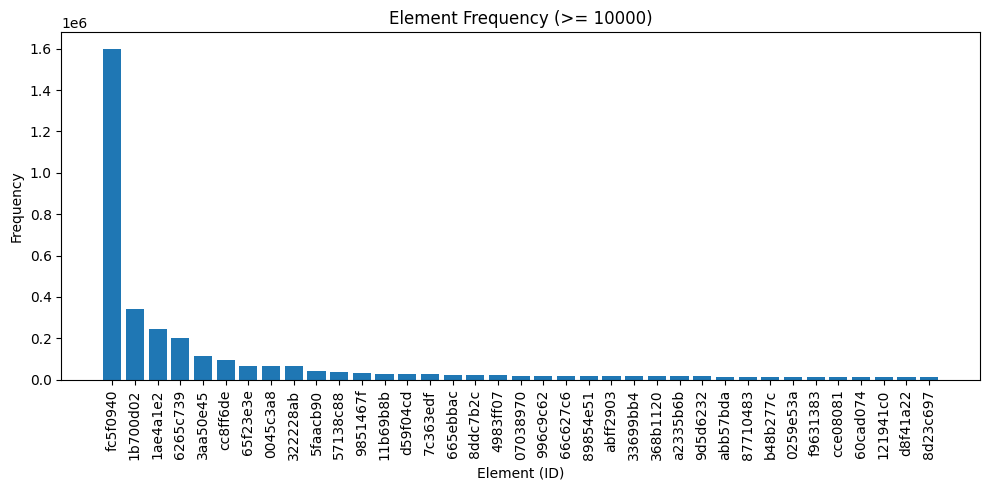

In [16]:
#BGL
plot_element_frequency(PROCESSED_DIR / "BGL/time/train", 10000)

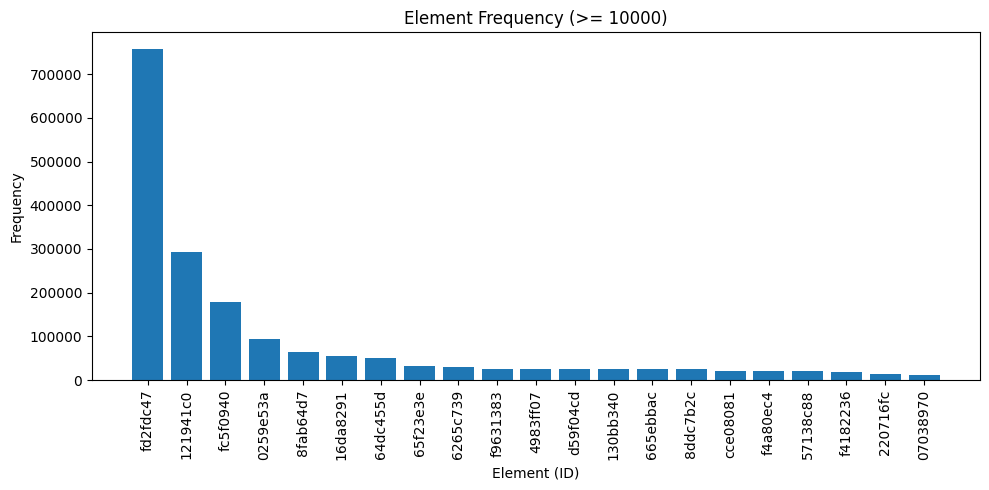

In [17]:
#BGL
plot_element_frequency(PROCESSED_DIR / "BGL/time/test_abnormal", 10000)

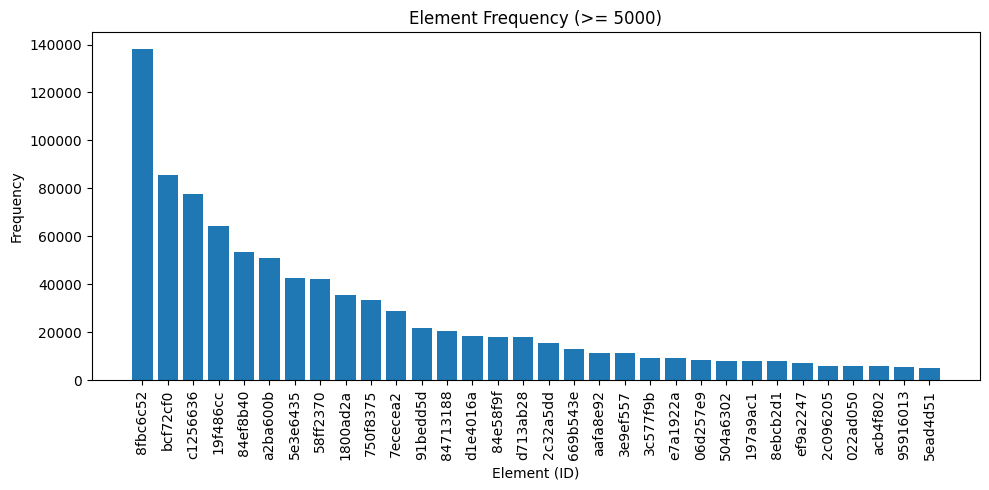

In [31]:
#Tbird
plot_element_frequency(PROCESSED_DIR / "Tbird/time/train", 5000)

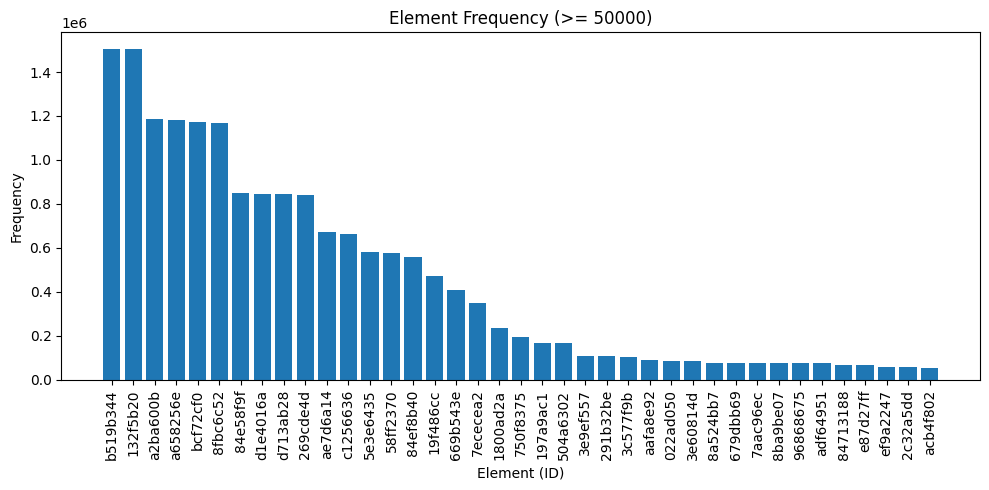

In [33]:
#Tbird
plot_element_frequency(PROCESSED_DIR / "Tbird/time/test_abnormal", 50000)

### windows
- 異常データも正常データもDrainでのIDの頻度分布が変わらない
- そのうえ、かなりログ分布が極端
- 全ログを参照するので、あまりウィンドウの分け方に依存しないこと注意！

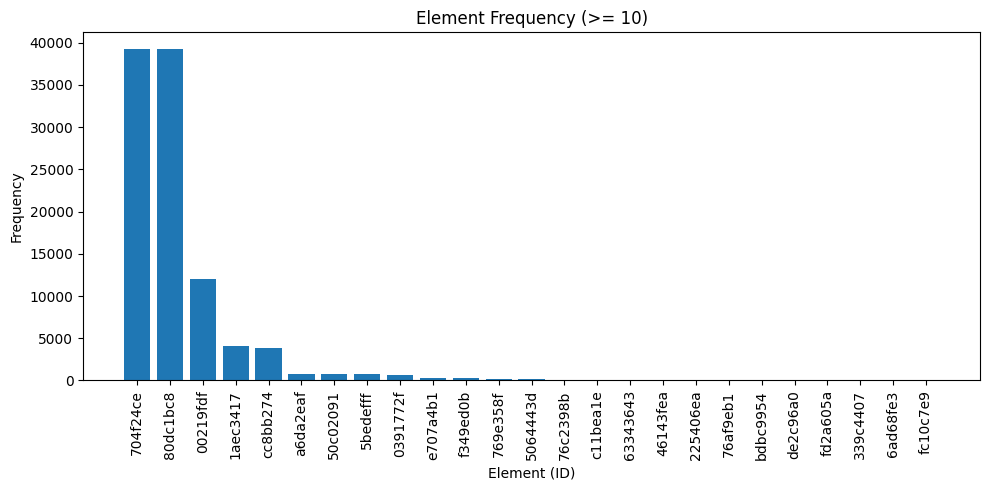

In [23]:
# windows
plot_element_frequency(PROCESSED_DIR / "refine/time/test_abnormal", 10)

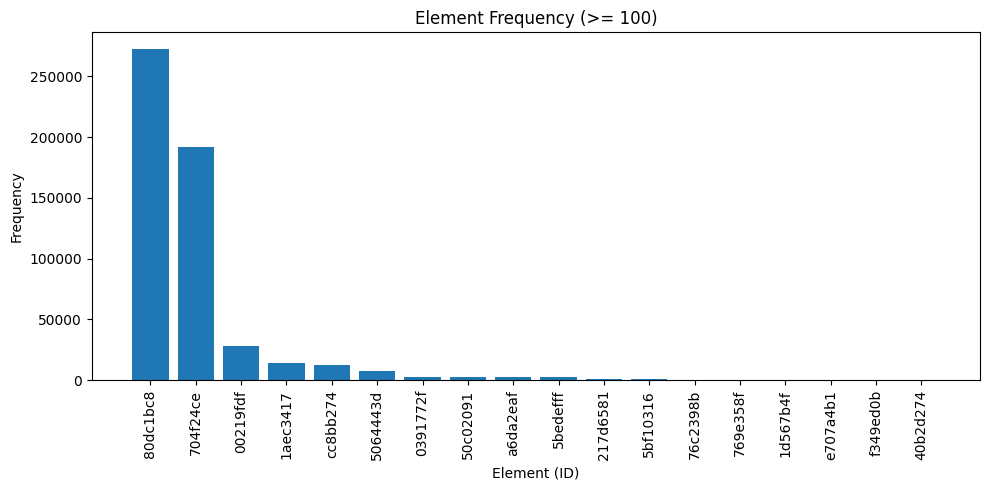

In [25]:
plot_element_frequency(PROCESSED_DIR / "refine/time/test_normal", 100)

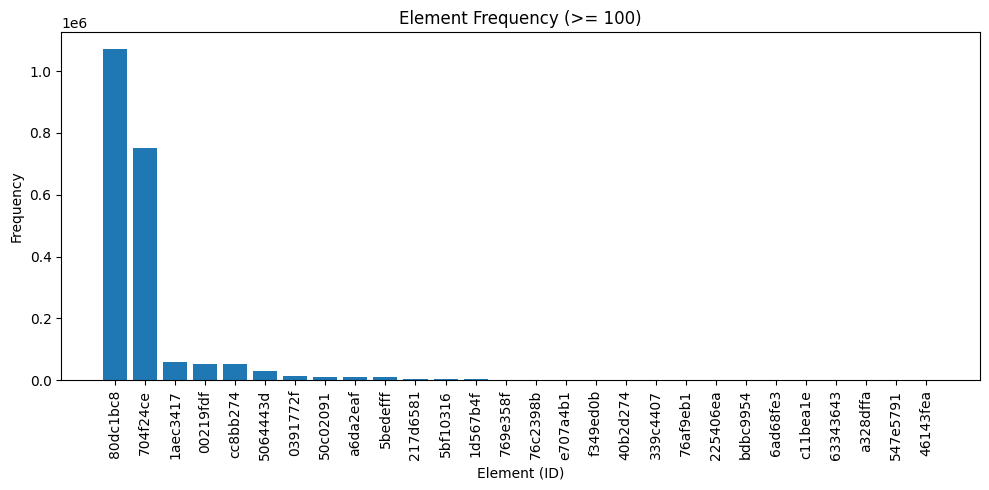

In [24]:
plot_element_frequency(PROCESSED_DIR / "refine/time/train", 100)

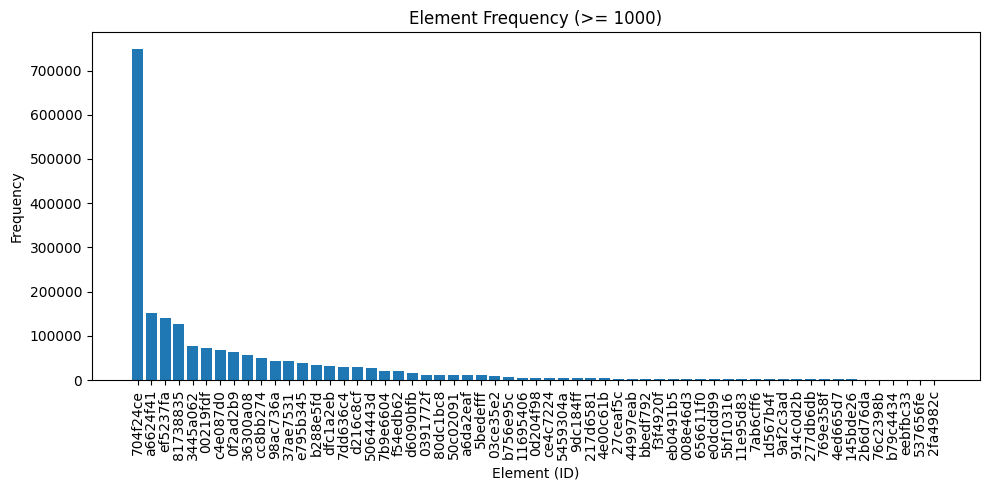

In [26]:
plot_element_frequency(PROCESSED_DIR / "refine2/fixed/train", 1000)

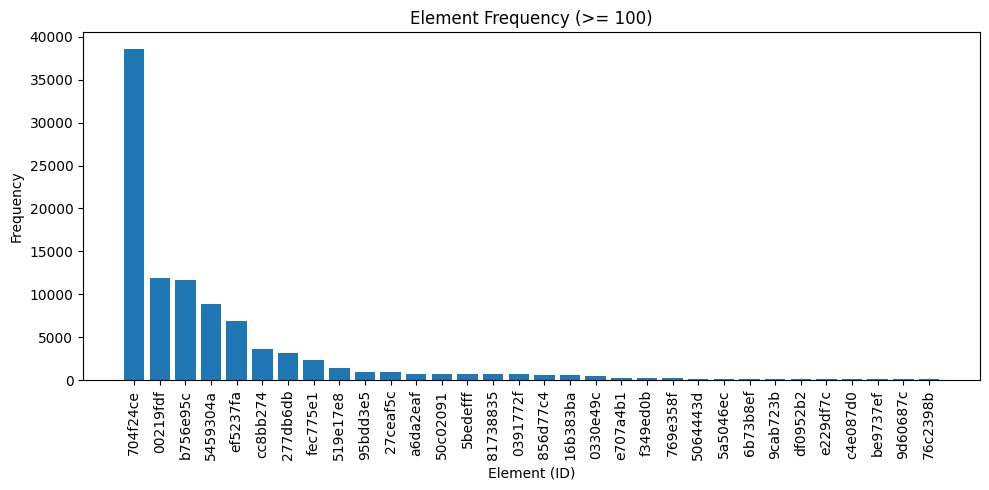

In [28]:
plot_element_frequency(PROCESSED_DIR / "refine2/fixed/test_abnormal", 100)

In [18]:
df = pd.read_csv(INTERIM_DIR/"WEB1/security2.csv")
print(df.loc[df["EventID"] == 5156, "Content"].count())
print(df.loc[df["EventID"] == 5156, "Content"].nunique())
print(df.loc[df["EventID"] == 5158, "Content"].count())
print(df.loc[df["EventID"] == 5158, "Content"].nunique())

91075
52811
66203
59873


### windows(Drainパースの現状)

In [37]:
df = pd.read_csv(INTERIM_DIR/"refine/security2_templates.csv")

In [41]:
df_sorted = df.sort_values(by="Occurrences", ascending=False)

In [53]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(df_sorted)

,EventId,EventTemplate,Occurrences
1,80dc1bc8,ProcessID=<*>|Application=<*>|Direction=<*>|SourceAddress=<*>|SourcePort=<*>|DestAddress=<*>|DestPort=<*>|Protocol=<*>|FilterRTID=<*>|LayerName=<*>|LayerRTID=<*>|RemoteUserID=<*>|RemoteMachineID=<*>,712303
3,704f24ce,ProcessId=<*>|Application=<*>|SourceAddress=<*>|SourcePort=<*>|Protocol=<*>|FilterRTID=<*>|LayerName=<*>|LayerRTID=<*>,512187
0,00219fdf,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|ObjectServer=<*>|Service=<*>|PrivilegeList=<*>|ProcessId=<*>|ProcessName=<*>,53340
2,1aec3417,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|NewProcessId=<*>|NewProcessName=<*>|TokenElevationType=<*>|ProcessId=<*>|CommandLine=<*>|TargetUserSid=<*>|TargetUserName=<*>|TargetDomainName=<*>|TargetLogonId=<*>|ParentProcessName=<*>|MandatoryLabel=<*>,41301
12,cc8bb274,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|TaskName=<*>|TaskContentNew=<*>|ClientProcessStartKey=<*>|ClientProcessId=<*>|ParentProcessId=<*>|RpcCallClientLocality=<*>|FQDN=<*>,35427
19,5064443d,ProcessId=<*>|UserSid=<*>|UserName=<*>|ProviderKey=<*>|ProviderName=<*>|ChangeType=<*>|FilterKey=<*>|FilterName=<*>|FilterType=<*>|FilterId=<*>|LayerKey=<*>|LayerName=<*>|LayerId=<*>|Weight=<*>|Conditions=<*>|Action=<*>|CalloutKey=<*>|CalloutName=<*>,19784
17,0391772f,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|TargetName=<*>|Type=<*>|CountOfCredentialsReturned=<*>|ReadOperation=<*>|ReturnCode=<*>|ProcessCreationTime=<*>|ClientProcessId=<*>,8359
10,50c02091,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|TargetUserSid=<*>|TargetUserName=<*>|TargetDomainName=<*>|TargetLogonId=<*>|LogonType=<*>|EventIdx=<*>|EventCountTotal=<*>|GroupMembership=<*>,7500
9,a6da2eaf,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|TargetUserSid=<*>|TargetUserName=<*>|TargetDomainName=<*>|TargetLogonId=<*>|LogonType=<*>|LogonProcessName=<*>|AuthenticationPackageName=<*>|WorkstationName=<*>|LogonGuid=<*>|TransmittedServices=<*>|LmPackageName=<*>|KeyLength=<*>|ProcessId=<*>|ProcessName=<*>|IpAddress=<*>|IpPort=<*>|ImpersonationLevel=<*>|RestrictedAdminMode=<*>|TargetOutboundUserName=<*>|TargetOutboundDomainName=<*>|VirtualAccount=<*>|TargetLinkedLogonId=<*>|ElevatedToken=<*>,7494
11,5bedefff,SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|PrivilegeList=<*>,7473


In [47]:
event_dict = build_drain_eventid_mapping(INTERIM_DIR/"refine/security2_structured.csv")

In [ ]:
keys = ["80dc1bc8", "704f24ce", "00219fdf", "1aec3417", "cc8bb274", "5064443d"]
values = [event_dict[k] for k in keys]
values

[5156, 5158, 4673, 4688, 4702]

### windows イベントIDの分布

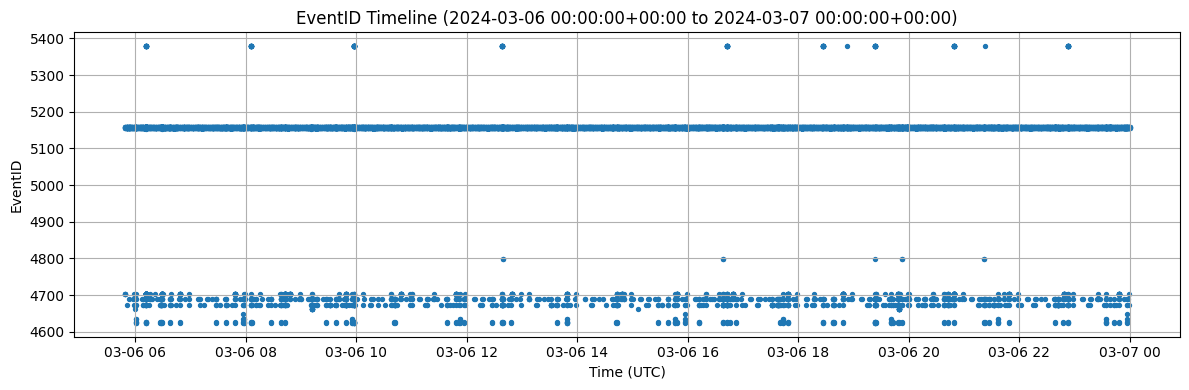

In [9]:
plot_eventid_timeline(
    csv_path=INTERIM_DIR/"WEB2/security2.csv",
    start="2024-03-06 00:00:00+00:00",
    end="2024-03-07 00:00:00+00:00",
)

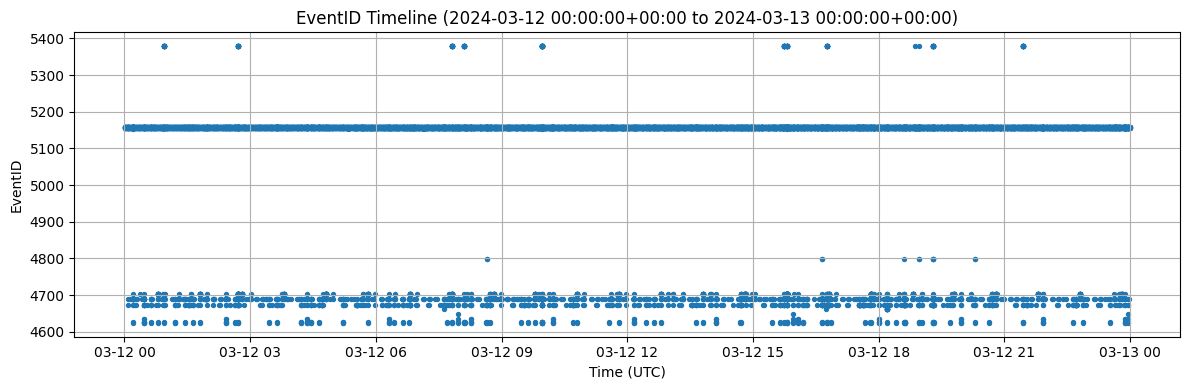

In [9]:
plot_eventid_timeline(
    csv_path=INTERIM_DIR/"WEB1/security2.csv",
    start="2024-03-12 00:00:00+00:00",
    end="2024-03-13 00:00:00+00:00",
)

In [14]:
plot_eventid_timeline(
    csv_path=INTERIM_DIR/"T1105/security2.csv",
    start="2024-08-24 00:00:00+00:00",
    end="2024-08-26 00:00:00+00:00",
)

指定した時間区間にデータがありません。


In [13]:
plot_eventid_timeline(
    csv_path=INTERIM_DIR/"T1105/security2.csv",
    start="2024-03-16 00:00:00+00:00",
    end="2024-03-17 00:00:00+00:00",
)

指定した時間区間にデータがありません。


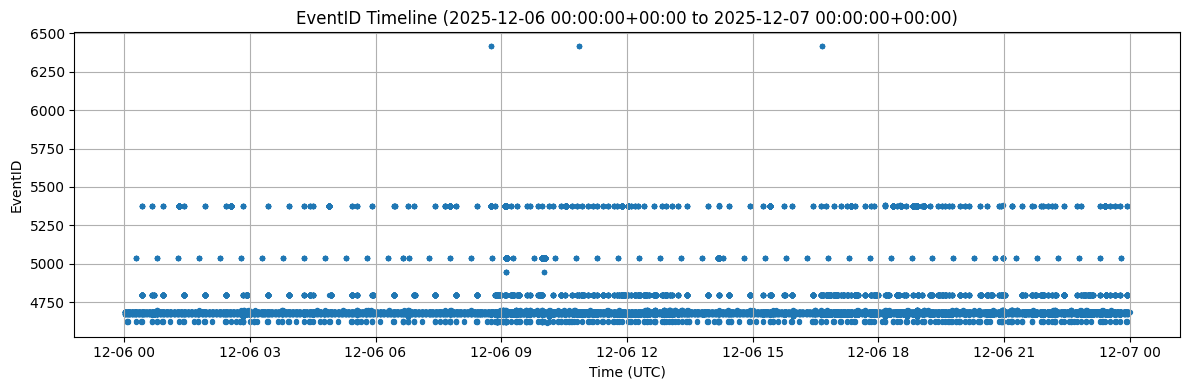

In [12]:
plot_eventid_timeline(
    csv_path=INTERIM_DIR/"My_logs/soraz/security2.csv",
    start="2025-12-06 00:00:00+00:00",
    end="2025-12-07 00:00:00+00:00",
)

## EventIDの各属性の頻度について

In [4]:
df = pd.read_csv(INTERIM_DIR/"refine/security2_structured.csv")

In [12]:
unique_json = export_event_unique_count_json(df, TMP_DIR / "Integrated/event_unique_count.json")

Output directory created: ../tmp/Integrated
DataFrame shape: (1366109, 25)
Columns: ['Unnamed: 0', 'LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']
Non-null records: 1366109
  Processed 10000 records...
  Processed 20000 records...
  Processed 30000 records...
  Processed 40000 records...
  Processed 50000 records...
  Processed 60000 records...
  Processed 70000 records...
  Processed 80000 records...
  Processed 90000 records...
  Processed 100000 records...
  Processed 110000 records...
  Processed 120000 records...
  Processed 130000 records...
  Processed 140000 records...
  Processed 150000 records...
  Processed 160000 records...
  Processed 170000 records...
  Processed 1

## プロセス関連

In [10]:
df = pd.read_csv(INTERIM_DIR/"WEB1/security2_structured.csv")

In [12]:
freq_df = count_processid_frequency(df)

In [15]:
freq_df.to_csv(TMP_DIR/"WEB1/processID_freq.csv",index=False)

In [25]:
summary_df = summarize_processid_with_names(df)
summary_df.to_csv(TMP_DIR/"WEB1/summary.csv", index=False)

## プロセスIDの分布

In [14]:
plot_column_value_frequency(
    csv_path = Path(INTERIM_DIR/"refine/security2_structured.csv"),
    column_name = "ProcessID",
    compare_labels = True,
    figsize=(14, 6)
)

KeyError: 'ProcessID'

## その他

In [3]:
df = pd.read_csv(INTERIM_DIR/'refine/security2_structured_unmasked.csv', index_col=0)

In [13]:
df["EventTemplateUnmaskedHash"]

LineId
1          00219fdf
2          00219fdf
3          cac10b8e
4          cac10b8e
5          cac10b8e
             ...   
1366105    704f24ce
1366106    704f24ce
1366107    9b51ca2c
1366108    704f24ce
1366109    ddd9a0f2
Name: EventTemplateUnmaskedHash, Length: 1366109, dtype: object

In [4]:
df["EventID"].value_counts()

EventID
5156    685614
5158    488200
4673     47366
4688     39423
4702     33558
5447     19694
5379      8028
5157      7310
4627      7116
4624      7116
4672      7091
5154      4503
4907      3980
4945      1800
4662       853
4799       678
4634       631
4798       488
4946       345
4957       336
4948       328
4663       222
4611       153
4776       135
6416       126
4797       121
4697       114
4648       114
4625       107
4985        92
4622        60
4701        45
4947        42
4674        40
5142        40
4698        35
4699        35
5061        20
4953        18
5140        17
4660        12
4614        12
4657        12
4700         8
4647         7
4944         6
4610         6
4696         6
4616         6
4902         6
4826         6
4778         6
4779         6
4800         6
5031         2
5382         2
4956         2
4717         2
4718         2
Name: count, dtype: int64

# その他

## 埋め込みのための準備

In [4]:
project = "WEB1"
df = pd.read_csv(INTERIM_DIR/f'{project}/security2.csv', index_col=0)

In [23]:
split_idx = int(len(df) * 0.7) # train側にanomalyが入らない割合で調整

df_train = df.iloc[:split_idx]
df_test = df.iloc[split_idx:]

In [24]:
for_embed.export_csv_per_eventid(
    df = df_train,
    output_dir=f"../eventid_content/{project}/test"
)
for_embed.export_csv_per_eventid(
    df = df_test,
    output_dir=f"../eventid_content/{project}/train"
)

## EventIDのグルーピング

In [11]:
event_attr_sets = for_embed.build_event_attribute_sets(df)

groups = for_embed.group_events_by_attribute_similarity(
    event_attr_sets,
    threshold=0.5
)

for i, g in enumerate(groups):
    print(f"Group {i}: {sorted(g)}")

Group 0: [1100, 4608]
Group 1: [4610]
Group 2: [4611, 4672, 4717, 4718, 4797, 5142]
Group 3: [4614]
Group 4: [4616, 4660, 4673, 4985]
Group 5: [4622]
Group 6: [4624, 4625]
Group 7: [4627, 4696]
Group 8: [4634, 4647, 4800]
Group 9: [4648]
Group 10: [4657]
Group 11: [4662, 4663, 4674]
Group 12: [4688]
Group 13: [4697]
Group 14: [4698, 4699, 4700, 4701, 4702]
Group 15: [4776]
Group 16: [4778, 4779]
Group 17: [4798, 4799]
Group 18: [4826]
Group 19: [4902]
Group 20: [4907]
Group 21: [4944]
Group 22: [4945, 4946, 4947, 4948, 4957]
Group 23: [4953]
Group 24: [4956]
Group 25: [5061]
Group 26: [5140]
Group 27: [5154, 5156, 5157, 5158]
Group 28: [5379]
Group 29: [5382]
Group 30: [5447]
Group 31: [6416]


# Score 開発関連

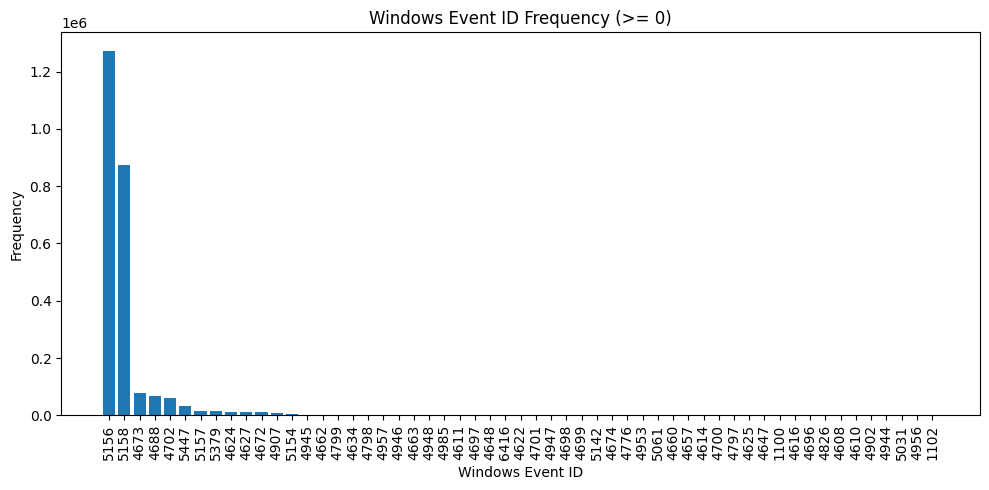

In [19]:
plot_windows_event_id_frequency(PROCESSED_DIR / "scores/fixed/train", 0)

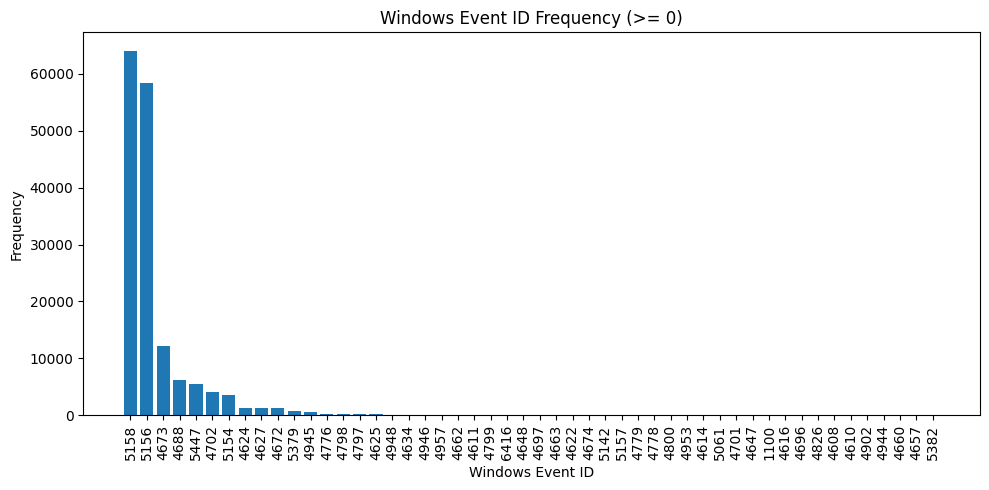

In [18]:
plot_windows_event_id_frequency(PROCESSED_DIR / "scores/fixed/test_normal", 0)

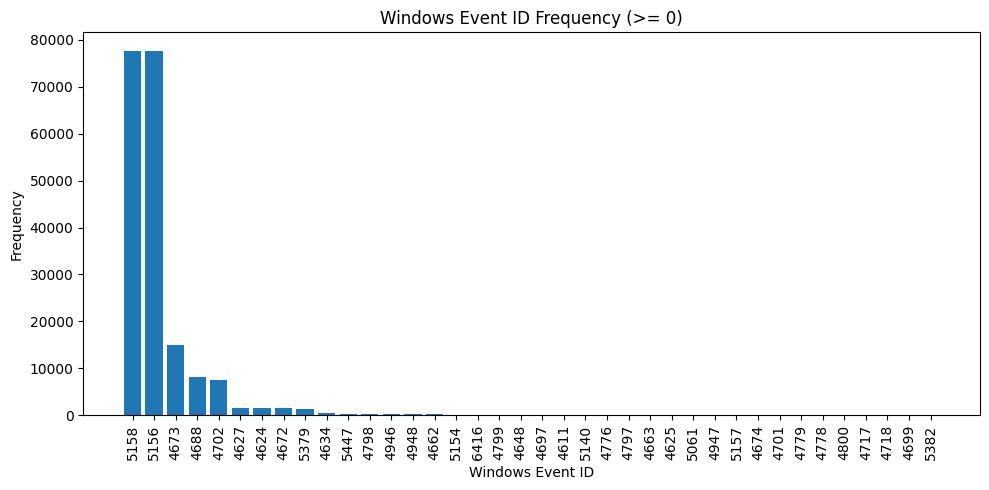

In [17]:
plot_windows_event_id_frequency(PROCESSED_DIR / "scores/fixed/test_abnormal", 0)

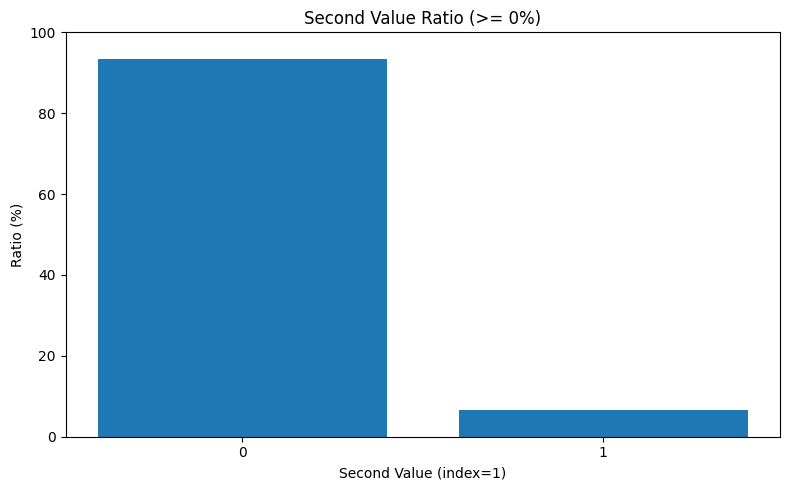

In [28]:
plot_second_value_ratio(PROCESSED_DIR / "scores/fixed/test_normal", 0)

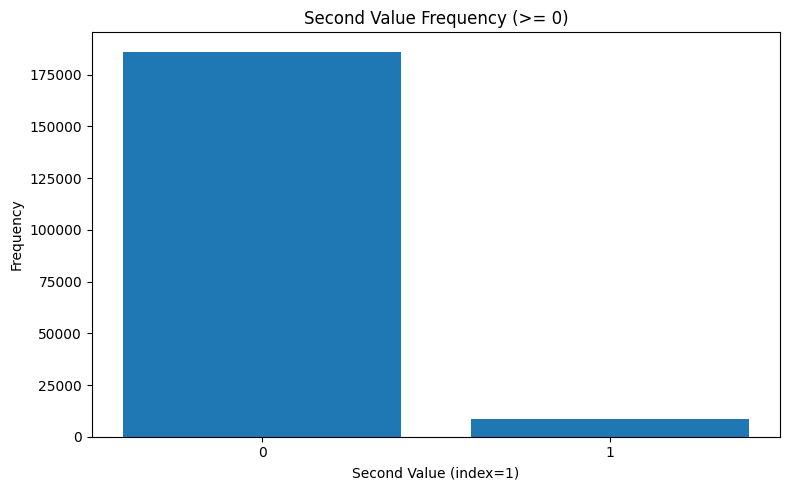

In [ ]:
plot_windows_event_id_ratio(PROCESSED_DIR / "scores/fixed/test_abnormal", 0)

# プロセスでグルーピング

In [4]:
csv_path = "/home/ubuntu/My_lad/data/interim/WEB1/security2.csv"
result = group_events_by_process(csv_path)
# サマリーを表示
print_summary(result)

処理結果サマリー
総行数: 194074
EventID 4688（プロセス生成）の数: 8534
一意なプロセス数: 8534
プロセスに紐付けられた行数: 58342
else（ProcessIDなし）の行数: 127198


In [6]:
# 特定プロセスの関連イベントを取得
for key, proc in result['processes'].items():
    print(f"プロセスID: {int(proc.process_id, 16)}, プロセス名: {proc.process_name},親プロセス名: {proc.parent_process_name}, ラベル: {proc.label}")
    for row_idx, row_data in proc.related_rows:
        print(f"行{row_idx}: EventID={row_data['EventID']}")

プロセスID: 4776, プロセス名: C:\Windows\System32\svchost.exe,親プロセス名: C:\Windows\System32\services.exe, ラベル: normal
行122: EventID=5158
行123: EventID=5158
行124: EventID=5156
行130: EventID=5158
行131: EventID=5156
プロセスID: 7532, プロセス名: C:\Users\taro\AppData\Local\Microsoft\OneDrive\24.025.0204.0003\FileCoAuth.exe,親プロセス名: C:\Windows\System32\svchost.exe, ラベル: normal
プロセスID: 1476, プロセス名: C:\Windows\System32\gpupdate.exe,親プロセス名: C:\Windows\System32\svchost.exe, ラベル: normal
プロセスID: 8572, プロセス名: C:\Windows\System32\conhost.exe,親プロセス名: C:\Windows\System32\gpupdate.exe, ラベル: normal
プロセスID: 6020, プロセス名: C:\Users\taro\AppData\Local\Microsoft\OneDrive\24.025.0204.0003\FileCoAuth.exe,親プロセス名: C:\Windows\System32\svchost.exe, ラベル: normal
プロセスID: 7772, プロセス名: C:\Windows\System32\svchost.exe,親プロセス名: C:\Windows\System32\services.exe, ラベル: normal
プロセスID: 6864, プロセス名: C:\Program Files (x86)\Microsoft\EdgeUpdate\MicrosoftEdgeUpdate.exe,親プロセス名: C:\Windows\System32\svchost.exe, ラベル: normal
プロセスID: 6692, プロセス名: C:\Windo